<a href="https://colab.research.google.com/github/amii-uwl-dba/northstar-analytics/blob/main/02_sql_r_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

print("Drive mounted")

Mounted at /content/drive
Drive mounted


In [2]:
%load_ext rpy2.ipython
print("R enabled")

R enabled


In [3]:
%%R
install.packages("sqldf")
install.packages("ggplot2")

library(sqldf)
library(ggplot2)

print("R libraries loaded successfully")

[1] "R libraries loaded successfully"


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’

trying URL 'https://cran.rstudio.com/src/contrib/gsubfn_0.7.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/proto_1.0.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RSQLite_2.4.6.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/chron_2.3-62.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/sqldf_0.4-12.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp56kFF1/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
Content type 'application/x-gzip' length 6327703 bytes (6.0 MB)
downloaded 6.0 MB


The downloaded source packages are in
	‘/tmp/Rtmp56kFF1/downloaded_packages’
Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite
In addi

In [4]:
%%R
deliveries <- read.csv("/content/drive/MyDrive/northstar_dataset/clean_deliveries.csv")
orders     <- read.csv("/content/drive/MyDrive/northstar_dataset/clean_orders.csv")
customers  <- read.csv("/content/drive/MyDrive/northstar_dataset/clean_customers.csv")
complaints <- read.csv("/content/drive/MyDrive/northstar_dataset/clean_complaints.csv")
drivers    <- read.csv("/content/drive/MyDrive/northstar_dataset/clean_drivers.csv")
hubs       <- read.csv("/content/drive/MyDrive/northstar_dataset/clean_hubs.csv")

print("Data loaded in R successfully")

[1] "Data loaded in R successfully"


In [5]:
%%R
query1 <- sqldf("
  SELECT h.hub_name, h.zone,
         COUNT(d.delivery_id) AS total_deliveries,
         SUM(d.failed_flag) AS total_failures,
         ROUND(AVG(d.failed_flag) * 100, 2) AS failure_rate_pct
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_name, h.zone
  ORDER BY failure_rate_pct DESC
")

print(query1)

        hub_name      zone total_deliveries total_failures failure_rate_pct
1  Midtown Relay   Central              128             26            20.31
2   Central Core   Central              115             23            20.00
3    Airport Hub   Airport              104             15            14.42
4      West Gate      West              127             16            12.60
5 North Exchange     North              136             17            12.50
6  Riverside Hub Riverside              115             14            12.17
7     South Link     South              106             10             9.43
8      East Dock      East              119             11             9.24


What This Query Shows

Midtown Relay and Central Core have the highest failure rates at 20% — both in the Central zone
South Link and East Dock perform best at around 9% failure rate
This is direct evidence that the Central zone is the most problematic for NorthStar

Midtown Relay and Central Core hubs both show 20% failure rates,
identifying the Central zone as NorthStar's most problematic area.
South Link and East Dock perform significantly better at around 9%.
Management should prioritise investigating Central zone operations.

In [8]:
#SQL Query 2: Driver Overrides vs Delivery Outcome
%%R
query2 <- sqldf("
  SELECT driver_id,
         COUNT(delivery_id) AS total_deliveries,
         SUM(manual_route_override_count) AS total_overrides,
         ROUND(AVG(failed_flag) * 100, 2) AS failure_rate_pct,
         ROUND(AVG(customer_rating_post_delivery), 2) AS avg_rating
  FROM deliveries
  GROUP BY driver_id
  ORDER BY total_overrides DESC
  LIMIT 10
")

print(query2)

   driver_id total_deliveries total_overrides failure_rate_pct avg_rating
1       D127                6              17             0.00       4.10
2       D130                8              16            12.50       3.83
3       D087               12              16            16.67       3.82
4       D131                9              15            33.33       3.66
5       D108               11              15            27.27       4.41
6       D105                7              14            14.29       4.21
7       D069                7              14            14.29       3.94
8       D028                7              13            14.29       3.54
9       D017               10              13            20.00       3.68
10      D104                7              12            57.14       3.93


What This Query Shows

D104 has 57% failure rate with 12 overrides — highest failure rate in the top 10
D131 has 33% failure rate with 15 overrides — also very concerning
D127 has 17 overrides but 0% failure rate — suggests overrides may be genuinely needed for this driver
High overrides don't always mean poor performance — but D104 and D131 need investigation

D104 shows the most concerning pattern with a 57% failure rate
and 12 manual overrides. D131 also shows high overrides and 33%
failure rate. However D127 has the most overrides but 0% failure
rate suggesting not all overrides indicate poor performance.
NorthStar should investigate D104 and D131 specifically.

In [9]:
# SQL Query 3: Complaints by Zone
%%R
query3 <- sqldf("
  SELECT o.pickup_zone,
         COUNT(c.complaint_id) AS total_complaints,
         ROUND(AVG(c.resolution_days), 2) AS avg_resolution_days,
         SUM(c.compensation_amount) AS total_compensation
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY total_complaints DESC
")

print(query3)

  pickup_zone total_complaints avg_resolution_days total_compensation
1       North               53                9.00           1141.095
2        East               50                6.82           1085.920
3       South               46                7.80            804.450
4   Riverside               45                7.73            898.700
5     Central               42                8.00           1002.500
6        West               34                8.74            766.720
7     Airport               32                7.19            463.345
8         Ctr               18                8.28            289.940


What This Query Shows

North zone has the most complaints at 53 followed by East at 50
North zone also has the highest average resolution time at 9 days — slowest to resolve
North zone has the highest total compensation at £1,141 — costing NorthStar the most
Airport zone has the least complaints at 32 and lowest compensation at £463

North zone generates the most complaints at 53 and takes the
longest to resolve at 9 days on average. This is also costing
NorthStar the most in compensation at £1,141. Airport zone
performs best with fewest complaints and lowest compensation
costs. NorthStar should prioritise improving service quality
in the North zone.

In [10]:
# SQL Query 4: Most Delayed Service Types
%%R
query4 <- sqldf("
  SELECT o.service_type,
         COUNT(d.delivery_id) AS total_deliveries,
         ROUND(AVG(d.delay_hrs), 2) AS avg_delay_hrs,
         ROUND(AVG(d.failed_flag) * 100, 2) AS failure_rate_pct,
         ROUND(AVG(d.cost_per_km), 2) AS avg_cost_per_km
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY avg_delay_hrs DESC
")

print(query4)

  service_type total_deliveries avg_delay_hrs failure_rate_pct avg_cost_per_km
1     Business              126          2.46            19.84            1.24
2      Medical              108          2.08            14.81            1.41
3    Passenger              262          2.05            14.50            1.21
4       Parcel              230          1.82            10.87            1.29
5       Retail              224          1.75            12.50            1.23


What This Query Shows

Business service has the highest average delay at 2.46 hours and highest failure rate at 19.84%
Medical service has the highest cost per km at £1.41 — most expensive to operate
Retail service performs best with lowest delays at 1.75 hours and low failure rate
Parcel service has the lowest failure rate at 10.87% — most reliable service type

Business service is the most problematic with the highest delay
of 2.46 hours and failure rate of 19.84%. Medical service is the
most expensive at £1.41 per km. Retail and Parcel services perform
best with lower delays and failure rates. NorthStar should
investigate why Business service consistently underperforms.

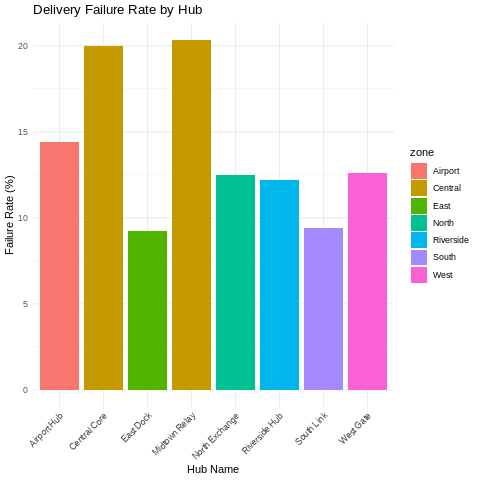

In [11]:
# R Visualisation with ggplot2
%%R
library(ggplot2)

ggplot(query1, aes(x=hub_name, y=failure_rate_pct, fill=zone)) +
  geom_bar(stat="identity") +
  theme_minimal() +
  labs(title="Delivery Failure Rate by Hub",
       x="Hub Name",
       y="Failure Rate (%)") +
  theme(axis.text.x = element_text(angle=45, hjust=1))

This R visualisation confirms the SQL findings. Central zone
hubs (Midtown Relay and Central Core) show the highest failure
rates at 20%. South Link and East Dock perform significantly
better. This pattern is consistent across both SQL analysis
and Python analytics.